In [ ]:
import subprocess

args = ["./sim"]
for fleet_size in (15000, 17500, 20000, 22500, 25000):
    with open(f"data/sim_configs/ann-arbor-{fleet_size}.txt", "w") as f:
        f.write(f"  length: {24 * 7 * 3600}\n")
        f.write(f"   pings: ann-arbor\n")
        f.write(f"  riders: ann-arbor-{fleet_size}\n")
        f.write(f"  output: ann-arbor-{fleet_size}\n")

        f.write(f"fm_cutoff_km: 1000\n")

        f.write(f"ev_charge_range: 400\n")
        f.write(f"ev_charge_time: 5400\n")
        f.write(f"ev_charge_threshold: 0.2\n")
        f.write(f"ev_charge_to: 0.8\n")

    args.append(f"ann-arbor-{fleet_size}")


subprocess.run(["cmake", "--build", "cmake-build-release", "--target", "sim", "-j", "8"], check=True)
subprocess.run(args, check=True)

[  8%] Built target tqdm
[ 21%] Built target pandas
[100%] Built target sim
reading reading data/riders/ann-arbor-25000.parquet
reading data/riders/ann-arbor-17500.parquet
reading data/riders/ann-arbor-22500.parquet
data/riders/ann-arbor-15000.parquet
reading data/riders/ann-arbor-20000.parquet
reading data/pings/ann-arbor.parquet
reading data/pings/ann-arbor.parquet
reading data/pings/ann-arbor.parquet
reading data/pings/ann-arbor.parquet
reading data/pings/ann-arbor.parquet


In [147]:
from tqdm.notebook import tqdm

outputs = []
stats = pd.DataFrame()

pings = pd.read_parquet(f"data_sim/pings/Washtenaw.parquet")

for fleet_size in tqdm(FLEET_SIZES):
    riders = pd.read_parquet(f"data_sim/riders/Washtenaw-{fleet_size}.parquet")
    riders = ls.RiderDataFrame(city, start, end, riders, timestamp_format="offset")

    output = pd.read_parquet(f"output/Washtenaw-{fleet_size}.parquet")
    del output["drop_time"]  # TODO remove this line if drop times may vary inside the sim

    output = pings.merge(output, left_index=True, right_index=True,
                         validate="1:1", how="left", suffixes=("_input", ""))
    output = ls.PingDataFrame(city, start, end, output, timestamp_format="offset")

    output.set_timestamp_format("datetime")
    output.compute_timestamps(drop=False)

    riders.set_timestamp_format("datetime")
    output.compute_prev_data(riders)

    run_stats = pd.DataFrame(output.compute_stats(), index=[0])
    run_stats["fleet_size"] = fleet_size
    stats = pd.concat([stats, run_stats], ignore_index=True)

    outputs.append(output)

del stats["start"], stats["end"], stats["city"]

stats.to_csv(f"output/Washtenaw-stats-{TOTAL_TIME_SECS}.csv")
stats.T

  0%|          | 0/4 [00:00<?, ?it/s]

,0,1,2,3
orders,5.719410e+06,5.719410e+06,5.719410e+06,5.719410e+06
delivered,4.349776e+06,5.214891e+06,5.676873e+06,5.719410e+06
acceptance,7.605288e+01,9.117883e+01,9.925627e+01,1.000000e+02
mean_fm_dist,2.474999e+00,1.579716e+00,1.047352e+00,9.088776e-01
mean_lm_dist,4.006327e+00,4.011723e+00,4.020759e+00,4.021614e+00
mean_dist,6.481322e+00,5.591438e+00,5.068111e+00,4.930490e+00
mean_fm_time,3.704009e+00,2.361051e+00,1.562457e+00,1.354722e+00
mean_fm_speed,4.009168e+01,4.014441e+01,4.021942e+01,4.025375e+01
mean_lm_time,6.001163e+00,6.009255e+00,6.022807e+00,6.024089e+00
mean_lm_speed,4.005551e+01,4.005544e+01,4.005533e+01,4.005533e+01


In [148]:
from dataclasses import dataclass
from shared.plot import *


@dataclass
class Compare:
    name: str
    actual: pd.Series
    simulated: pd.Series


def plot_comparision(*args: Compare, colors=("#2563eb", "#eb4971", "#ebad49"), **kwargs):
    series = []
    for i, metric in enumerate(args):
        series.append(PlotSeries(metric.actual, name=metric.name, color=colors[i]))
        series.append(
            PlotSeries(metric.simulated, name=metric.name, color=colors[i], style="dashed", width=1, legend=False))

    plot_lines(*series, **kwargs, figsize=(20, 3))


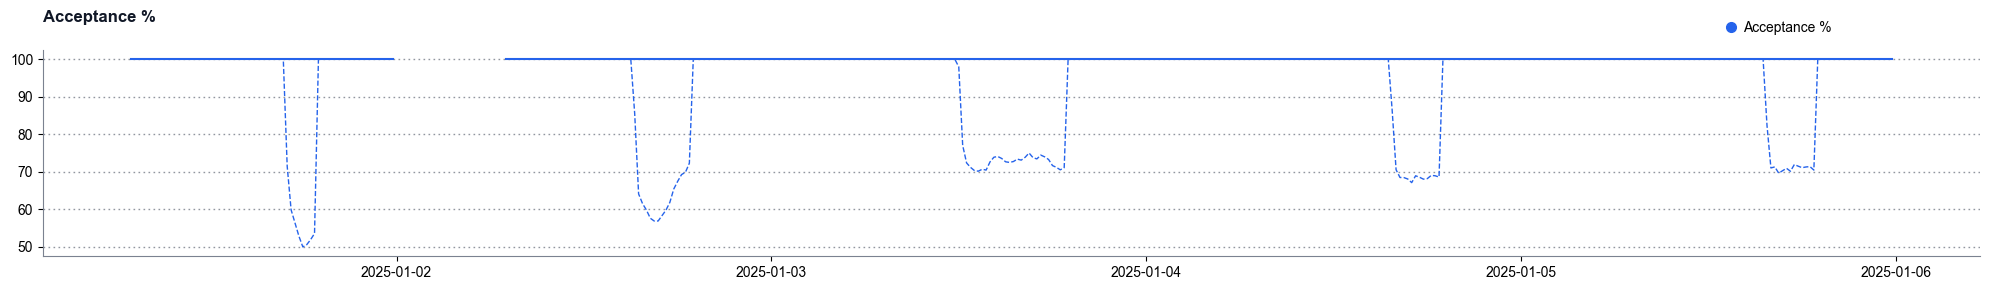

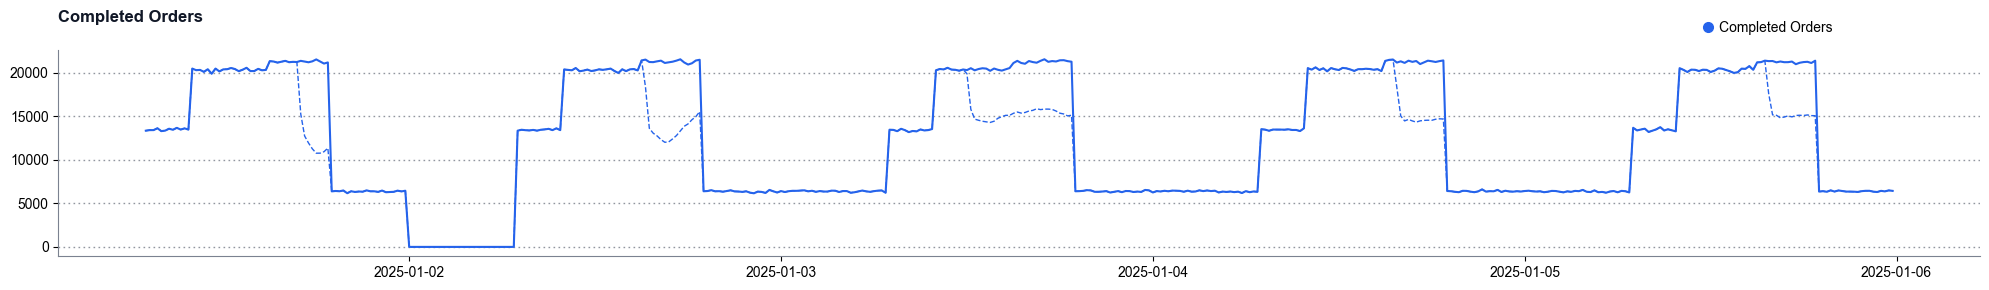

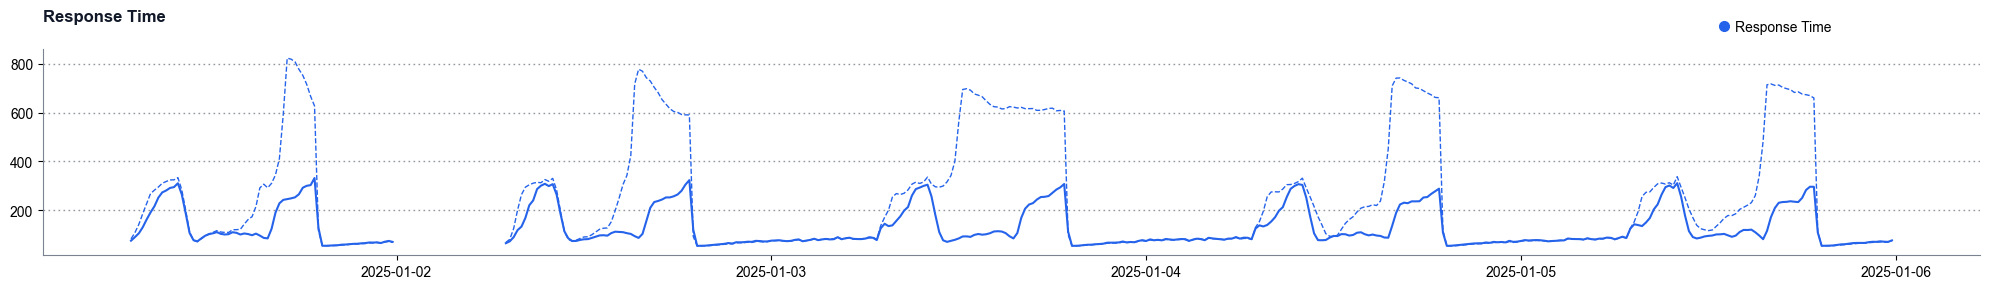

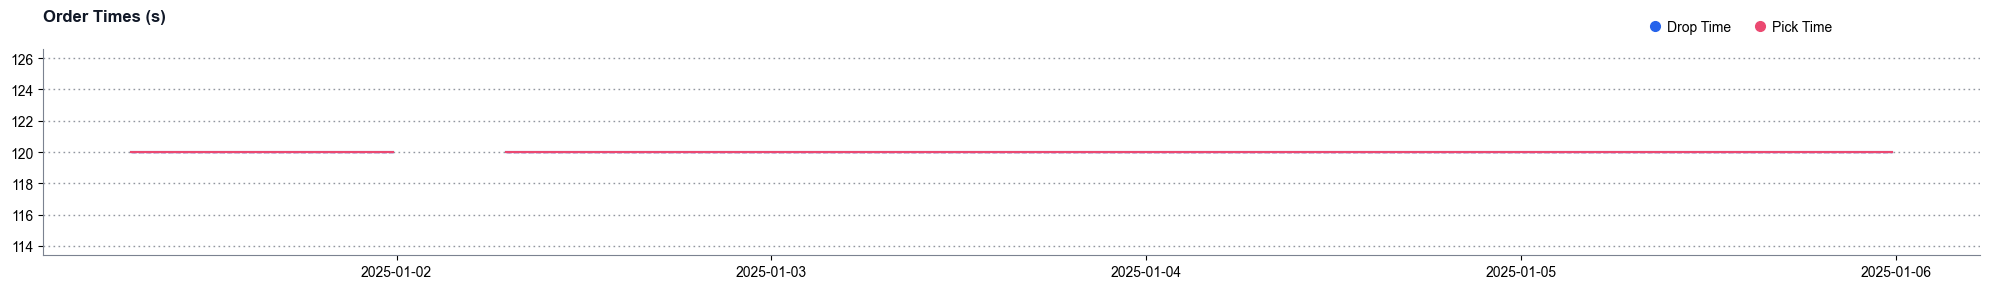

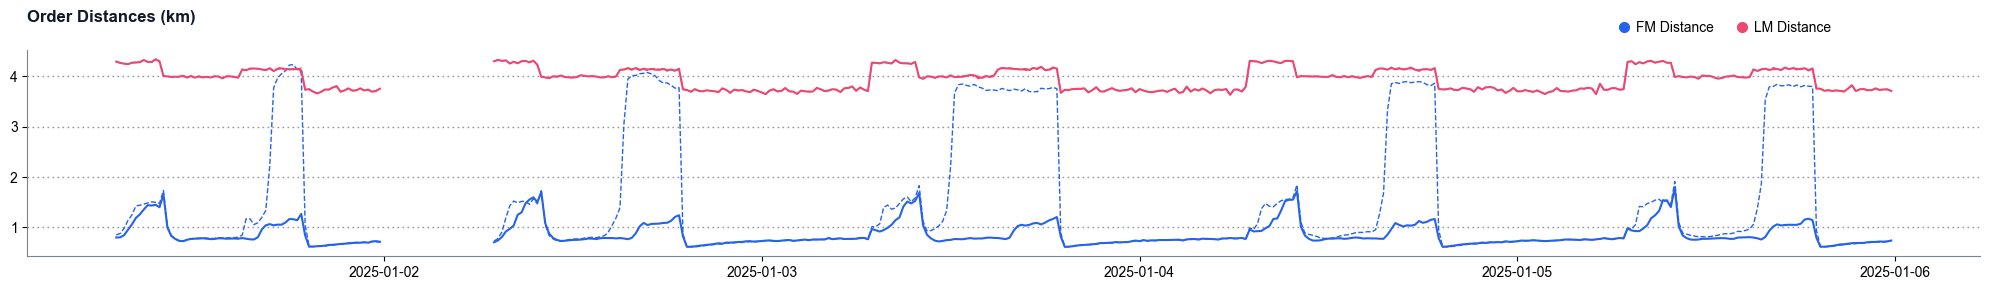

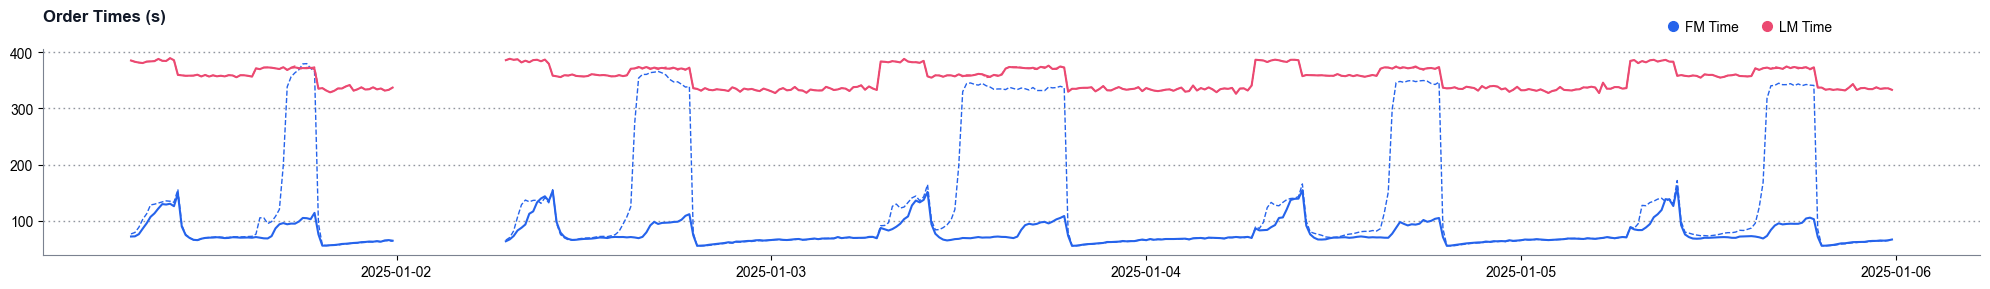

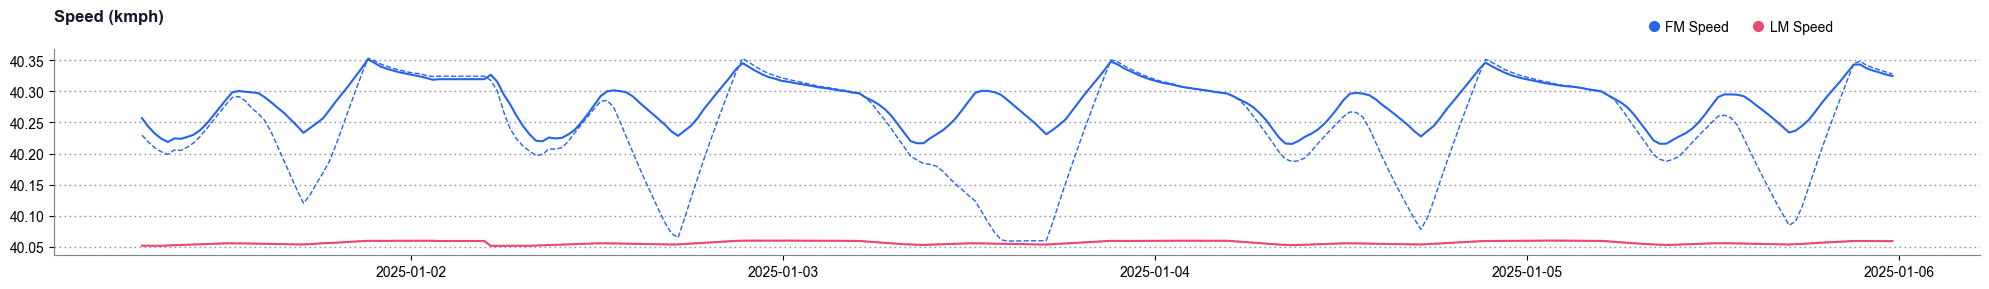

In [151]:
pings1 = outputs[-1]
pings2 = outputs[-3]


def resample(df):
    return df.resample("900s", on="created_at").mean()


def compute_completed_orders(df):
    return df[df["completed"]].resample("900s", on="created_at").size()

def compute_response_time(df):
    df["response_time"] = (df["arrived_pick_at"] - df["created_at"]).dt.total_seconds()


compute_response_time(pings1)
compute_response_time(pings2)

subtitle = f""

acceptance = 100 * resample(pings1[["created_at", "completed"]])
sim_acceptance = 100 * resample(pings2[["created_at", "completed"]])

cols = ["created_at", "fm_dist", "lm_dist", "drop_time", "pick_time", "fm_time", "wait_time", "lm_time", "response_time"]
actual_stats = resample(pings1[pings1["completed"]][cols])
sim_stats = resample(pings2[pings2["completed"]][cols])

fm_speeds, lm_speeds = compute_historical_speeds(pings1)
sim_fm_speeds, sim_lm_speeds = compute_historical_speeds(pings2)

plot_comparision(Compare("Acceptance %", acceptance, sim_acceptance), title="Acceptance %", subtitle=subtitle)

plot_comparision(Compare("Completed Orders", compute_completed_orders(pings1), compute_completed_orders(pings2)),
                 title="Completed Orders", subtitle=subtitle)

plot_comparision(Compare("Response Time", actual_stats["response_time"], sim_stats["response_time"]),
                 title="Response Time", subtitle=subtitle)

plot_comparision(Compare("Drop Time", actual_stats["drop_time"], sim_stats["drop_time"]),
                 Compare("Pick Time", actual_stats["pick_time"], sim_stats["pick_time"]),
                 title="Order Times (s)", subtitle=subtitle)

plot_comparision(Compare("FM Distance", actual_stats["fm_dist"], sim_stats["fm_dist"]),
                 Compare("LM Distance", actual_stats["lm_dist"], sim_stats["lm_dist"]),
                 title="Order Distances (km)", subtitle=subtitle)

plot_comparision(Compare("FM Time", actual_stats["fm_time"], sim_stats["fm_time"]),
                 Compare("LM Time", actual_stats["lm_time"], sim_stats["lm_time"]),
                 title="Order Times (s)", subtitle=subtitle)

plot_comparision(Compare("FM Speed", fm_speeds, sim_fm_speeds),
                 Compare("LM Speed", lm_speeds, sim_lm_speeds),
                 title="Speed (kmph)", subtitle=subtitle)

In [124]:
INTERCHANGES_RAW = [
    {"type": "Polygon", "coordinates": [[[-83.7653053184995, 42.24695964710352], [-83.7653053184995, 42.24509281118205],
                                         [-83.76275861187068, 42.24509281118205],
                                         [-83.76275861187068, 42.24695964710352],
                                         [-83.7653053184995, 42.24695964710352]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.74015017566227, 42.23774097697641], [-83.74015017566227, 42.23605048903499],
         [-83.73792020364262, 42.23605048903499], [-83.73792020364262, 42.23774097697641],
         [-83.74015017566227, 42.23774097697641]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.68660719232598, 42.22658232594573], [-83.68660719232598, 42.224802767846434],
         [-83.68424050321555, 42.224802767846434], [-83.68424050321555, 42.22658232594573],
         [-83.68660719232598, 42.22658232594573]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.68519752285086, 42.25546774214873], [-83.68519752285086, 42.2537539885268],
         [-83.68270093245769, 42.2537539885268], [-83.68270093245769, 42.25546774214873],
         [-83.68519752285086, 42.25546774214873]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.68857539500242, 42.307200975706685], [-83.68857539500242, 42.3054901375886],
         [-83.68609755756299, 42.3054901375886], [-83.68609755756299, 42.307200975706685],
         [-83.68857539500242, 42.307200975706685]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.74855035499152, 42.301261500288085], [-83.74855035499152, 42.29988261363462],
         [-83.74655327973984, 42.29988261363462], [-83.74655327973984, 42.301261500288085],
         [-83.74855035499152, 42.301261500288085]]]},

    {"type": "Polygon", "coordinates": [
        [[-83.78825960166517, 42.299086240275884], [-83.78825960166517, 42.29751961679856],
         [-83.78595539072994, 42.29751961679856], [-83.78595539072994, 42.299086240275884],
         [-83.78825960166517, 42.299086240275884]]]}
]

OVERPASSES_RAW = [
    {"type": "Polygon", "coordinates": [
        [[-83.72065443320648, 42.237651471473384], [-83.72065443320648, 42.23686885402677],
         [-83.71965779814654, 42.23686885402677], [-83.71965779814654, 42.237651471473384],
         [-83.72065443320648, 42.237651471473384]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70013643938798, 42.23263938226738], [-83.70013643938798, 42.23191794854806],
         [-83.69935695982517, 42.23191794854806], [-83.69935695982517, 42.23263938226738],
         [-83.70013643938798, 42.23263938226738]]]},
    {"type": "Polygon", "coordinates": [[[-83.6860436272189, 42.2309475936862], [-83.6860436272189, 42.23024168958983],
                                         [-83.68496888780194, 42.23024168958983],
                                         [-83.68496888780194, 42.2309475936862],
                                         [-83.6860436272189, 42.2309475936862]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.68403816600447, 42.24578228019548], [-83.68403816600447, 42.24515231376033],
         [-83.6831281692095, 42.24515231376033], [-83.6831281692095, 42.24578228019548],
         [-83.68403816600447, 42.24578228019548]]]},
    {"type": "Polygon", "coordinates": [[[-83.6831712809513, 42.29502296896619], [-83.6831712809513, 42.29410786241498],
                                         [-83.68209171348968, 42.29410786241498],
                                         [-83.68209171348968, 42.29502296896619],
                                         [-83.6831712809513, 42.29502296896619]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.70828346106319, 42.32429627193206], [-83.70828346106319, 42.323685932804864],
         [-83.70744465315146, 42.323685932804864], [-83.70744465315146, 42.32429627193206],
         [-83.70828346106319, 42.32429627193206]]]},
    {"type": "Polygon", "coordinates": [[[-83.73583255375239, 42.32023765134], [-83.73583255375239, 42.31941550032116],
                                         [-83.73486407734694, 42.31941550032116], [-83.73486407734694, 42.32023765134],
                                         [-83.73583255375239, 42.32023765134]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.76626238447042, 42.2993415694097], [-83.76626238447042, 42.29872522220684],
         [-83.76544945524273, 42.29872522220684], [-83.76544945524273, 42.2993415694097],
         [-83.76626238447042, 42.2993415694097]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.80025005101768, 42.29079492822921], [-83.80025005101768, 42.289853415187515],
         [-83.7988783537706, 42.289853415187515], [-83.7988783537706, 42.29079492822921],
         [-83.80025005101768, 42.29079492822921]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78337787301311, 42.28208581687849], [-83.78485546123454, 42.28208581687849],
         [-83.78485546123454, 42.28107150027606], [-83.78337787301311, 42.28107150027606],
         [-83.78337787301311, 42.28208581687849]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.78480983499519, 42.27312583402841], [-83.78480983499519, 42.27226297526143],
         [-83.78384466454183, 42.27226297526143], [-83.78384466454183, 42.27312583402841],
         [-83.78480983499519, 42.27312583402841]]]},
    {"type": "Polygon", "coordinates": [
        [[-83.77661422170391, 42.256574286289904], [-83.77800450587073, 42.256574286289904],
         [-83.77800450587073, 42.255639763725604], [-83.77661422170391, 42.255639763725604],
         [-83.77661422170391, 42.256574286289904]]]},
]

for interchange in OVERPASSES_RAW:
    lons, lats = zip(*interchange["coordinates"][0])
    mean_lon = np.mean(lons)
    mean_lat = np.mean(lats)
    print(f"[{mean_lon}, {mean_lat}],")

[-83.72025577918251, 42.23733842449474],
[-83.69982464756285, 42.23235080877966],
[-83.68561373145211, 42.230665232047656],
[-83.68367416728648, 42.24553029362142],
[-83.68273945396665, 42.2946569263457],
[-83.70794793789851, 42.32405213628119],
[-83.7354451631902, 42.319908790932466],
[-83.76593721277933, 42.299095030528555],
[-83.79970137211885, 42.29041832301253],
[-83.78396890830167, 42.281680090237515],
[-83.78442376681384, 42.27278069052162],
[-83.77717033537063, 42.25620047726419],
